<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/1_spam_message_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip install optuna

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from wordcloud import WordCloud
import nltk
import string
import re
from nltk.tokenize  import word_tokenize,sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold


from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import optuna
from optuna.samplers import TPESampler





[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Data Loading & Cleaning**

In [36]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

In [37]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1836,ham,Are you wet right now?,NaN,NaN,NaN
3402,ham,Good night my dear.. Sleepwell&amp;Take care,NaN,NaN,NaN
3494,spam,Wan2 win a Meet+Greet with Westlife 4 U or a m...,NaN,NaN,NaN
450,ham,hanks lotsly!,NaN,NaN,NaN
3214,ham,I want snow. It's just freezing and windy.,NaN,NaN,NaN


In [38]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [39]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [40]:
df.shape

(5572, 2)

In [41]:
df.isna().sum()

,0
v1,0
v2,0


In [42]:
df.duplicated().sum()

np.int64(403)

In [43]:
df.drop_duplicates(inplace=True)

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)

In [46]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


** Exploratory Data Analysis (EDA)**

label
ham     4516
spam     653
Name: count, dtype: int64
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


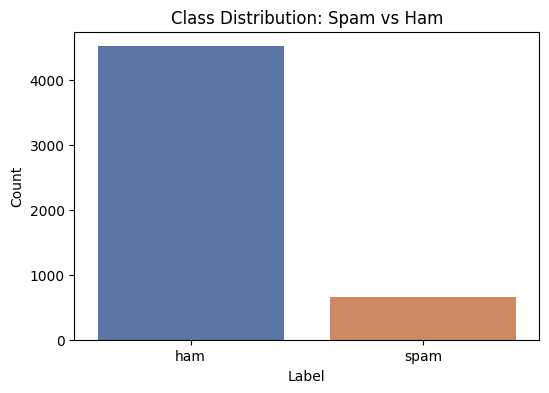

In [47]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette=['#4C72B0', '#DD8452'])
plt.title('Class Distribution: Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

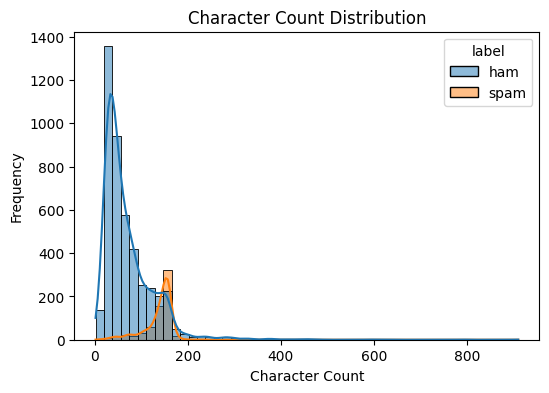

In [48]:
# message length analysis
df['char_count'] = df['message'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(data=df,x='char_count',kde=True,color='#`4C72B0',hue='label', bins=50)
plt.title('Character Count Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()


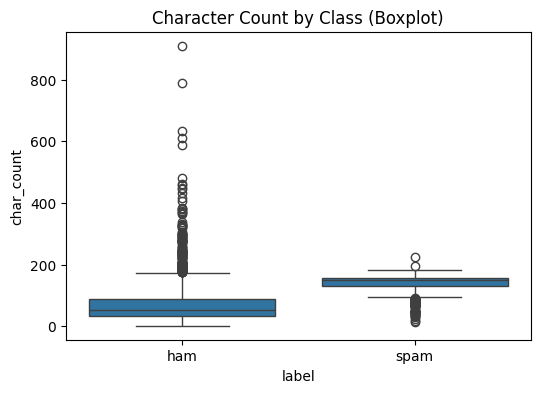

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


In [49]:
# boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='label', y='char_count')
plt.title('Character Count by Class (Boxplot)')
plt.show()

print(df.groupby('label')['char_count'].describe())

In [50]:
df

,label,message,char_count
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


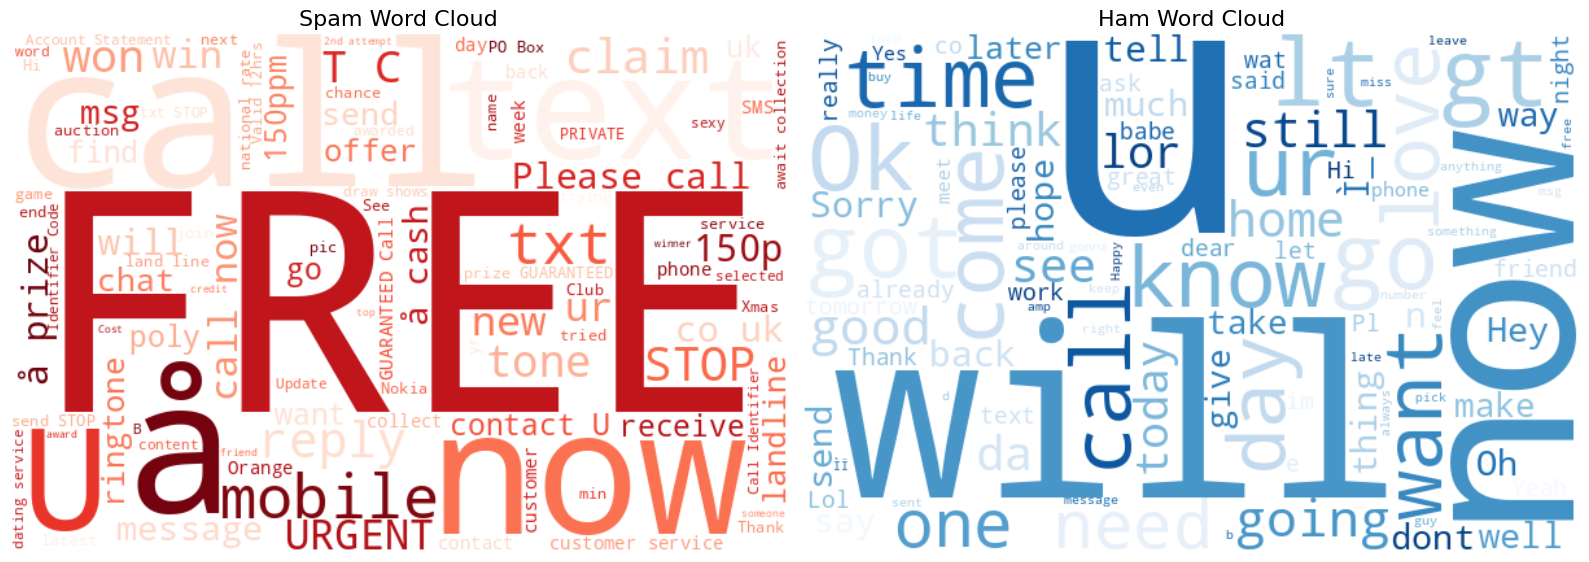

In [21]:
spam_text = ' '.join(df[df['label'] == 'spam']['message'])
ham_text = ' '.join(df[df['label'] == 'ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

spam_wc = WordCloud(width=600, height=400, background_color='white',
                     colormap='Reds', max_words=100).generate(spam_text)
axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].set_title('Spam Word Cloud', fontsize=16)
axes[0].axis('off')

ham_wc = WordCloud(width=600, height=400, background_color='white',
                    colormap='Blues', max_words=100).generate(ham_text)
axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].set_title('Ham Word Cloud', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Character/Word/Sentence Counts as Engineered Features
df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(word_tokenize(x)))
df['sentence_count'] = df['message'].apply(lambda x: len(sent_tokenize(x)))

# Optional extra features that often help spam detection
df['avg_word_length'] = df['char_count'] / df['word_count'].replace(0, 1)
df['upper_case_count'] = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['digit_count'] = df['message'].apply(lambda x: sum(1 for c in x if c.isdigit()))
df['special_char_count'] = df['message'].apply(lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()))

df.groupby('label')[['char_count', 'word_count', 'sentence_count',
                      'avg_word_length', 'digit_count']].mean()

,char_count,word_count,sentence_count,avg_word_length,digit_count
label,,,,,
ham,70.459256,17.123782,1.820195,4.125416,0.290301
spam,137.891271,27.667688,2.970904,5.077816,15.447167


In [23]:
df

,label,message,char_count,word_count,sentence_count,avg_word_length,upper_case_count,digit_count,special_char_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,4.625000,3,0,9
1,ham,Ok lar... Joking wif u oni...,29,8,2,3.625000,2,0,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,4.189189,10,25,6
3,ham,U dun say so early hor... U c already then say...,49,13,1,3.769231,2,0,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,4.066667,2,0,2
...,...,...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4,4.600000,9,21,9
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1,4.111111,2,0,2
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2,3.800000,2,0,7
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1,4.629630,2,0,1


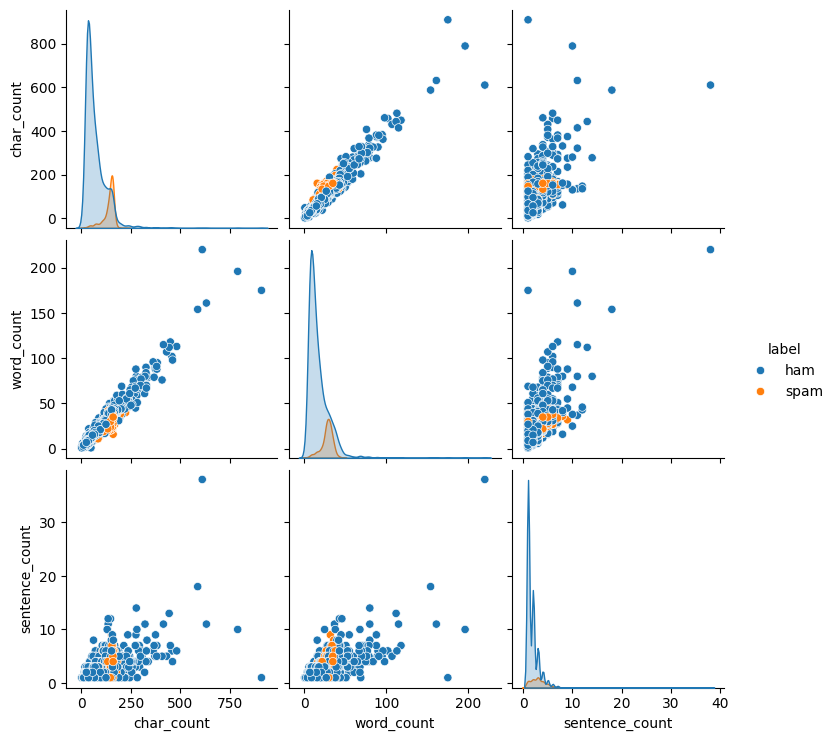

In [24]:
# Pairplot to see how these features separate the classes together:
sns.pairplot(df, vars=['char_count', 'word_count', 'sentence_count'], hue='label')
plt.show()

**Text Preprocessing**

In [25]:
# preprocesssing function
def preprocessing(text,use_lemmatization=True):
  # lower case
  text=text.lower()

  # 2. Removing punctuation, numbers, special characters
  text = re.sub(r'[^a-z\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()

  # 3. Tokenization
  tokens=word_tokenize(text)

  # 4. Removing Stopwords
  stop_words = set(stopwords.words('english'))
  tokens = [word for word in tokens if word not in stop_words]

  # 5. Stemming or Lemmatization
  if use_lemmatization:
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
  else:
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]

  return tokens



In [26]:
# applying the preprocess to the data
df['tokens'] = df['message'].apply(lambda x: preprocessing(x))
df['clean_message'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))


In [27]:
df

,label,message,char_count,word_count,sentence_count,avg_word_length,upper_case_count,digit_count,special_char_count,tokens,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,4.625000,3,0,9,"[go, jurong, point, crazy, available, bugis, n...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,8,2,3.625000,2,0,6,"[ok, lar, joking, wif, u, oni]",ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,4.189189,10,25,6,"[free, entry, wkly, comp, win, fa, cup, final,...",free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,49,13,1,3.769231,2,0,6,"[u, dun, say, early, hor, u, c, already, say]",u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,4.066667,2,0,2,"[nah, dont, think, go, usf, life, around, though]",nah dont think go usf life around though
...,...,...,...,...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4,4.600000,9,21,9,"[nd, time, tried, contact, u, u, pound, prize,...",nd time tried contact u u pound prize claim ea...
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1,4.111111,2,0,2,"[b, going, esplanade, fr, home]",b going esplanade fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2,3.800000,2,0,7,"[pity, mood, soany, suggestion]",pity mood soany suggestion
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1,4.629630,2,0,1,"[guy, bitching, acted, like, id, interested, b...",guy bitching acted like id interested buying s...


**feature Extraction**

In [28]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1,2))

In [29]:
X = df['clean_message']
y = df['label'].map({'ham': 0, 'spam': 1})

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [31]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

**Modeling**

In [32]:
# objective function
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial,X,y):
  # suggest the model itself as hyperparameter
  model_name = trial.suggest_categorical('model', ['RandomForestClassifier', 'NaiveBayes'])

  # define model specific hyperparamter
  if model_name == 'RandomForestClassifier':
    paramas={
        'max_depth':trial.suggest_int('max_depth',2,10),
        'min_samples_split':trial.suggest_int('min_samples_split',2,10),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,5),
        "n_jobs": -1,
        "random_state": 42,
    }
    model = RandomForestClassifier(**paramas)
  elif model_name == 'NaiveBayes':
    paramas={
        "alpha": trial.suggest_float("alpha", 1e-10, 1.0, log=True),
        'fit_prior': trial.suggest_categorical(
            'fit_prior',
            [True, False]
        )
    }
    model = MultinomialNB(**paramas)
  else:
   raise ValueError("Invalid model type")
  score = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
  return score.mean()


In [51]:
# running the study
study=optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial,X_train,y_train),n_trials=50)
best_params = study.best_params.copy()
best_model_name = best_params.pop('model')

if best_model_name == 'RandomForestClassifier':
    best_params.update({'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42})
    final_model = RandomForestClassifier(**best_params)
else:
    final_model = MultinomialNB(**best_params)

final_model.fit(X_train, y_train)

print('Best trial: score {}, params {}'.format(study.best_trial.value, study.best_trial.params))

[I 2026-08-23 04:11:43,954] A new study created in memory with name: no-name-878c24ca-526a-405b-981d-ae8b6e69aef5
[I 2026-08-23 04:11:45,261] Trial 0 finished with value: 0.2501692945123808 and parameters: {'model': 'RandomForestClassifier', 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.2501692945123808.
[I 2026-08-23 04:11:45,315] Trial 1 finished with value: 0.8481789505918323 and parameters: {'model': 'NaiveBayes', 'alpha': 0.07154135771742168, 'fit_prior': False}. Best is trial 1 with value: 0.8481789505918323.
[I 2026-08-23 04:11:45,381] Trial 2 finished with value: 0.8530657388625584 and parameters: {'model': 'NaiveBayes', 'alpha': 2.840883516332124e-06, 'fit_prior': False}. Best is trial 2 with value: 0.8530657388625584.
[I 2026-08-23 04:11:45,448] Trial 3 finished with value: 0.8541410076797629 and parameters: {'model': 'NaiveBayes', 'alpha': 4.7218881122836485e-05, 'fit_prior': False}. Best is trial 3 with value: 0.85414100767976

Best trial: score 0.9136846733668342, params {'model': 'NaiveBayes', 'alpha': 0.2893151257855347, 'fit_prior': True}


In [54]:
y_pred=final_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       903
        spam       0.97      0.82      0.89       131

    accuracy                           0.97      1034
   macro avg       0.97      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034


Confusion Matrix:
[[900   3]
 [ 24 107]]


**predict the message**

In [55]:
def predict_message(raw_message, vectorizer, model, use_lemmatization=True):
    # 1. Preprocess exactly like training (same function, same flag)
    tokens = preprocessing(raw_message, use_lemmatization=use_lemmatization)
    cleaned = ' '.join(tokens)

    # 2. Vectorize using the SAME fitted TF-IDF vectorizer (transform, not fit_transform)
    vectorized = vectorizer.transform([cleaned])

    # 3. Predict
    pred = model.predict(vectorized)[0]
    label = "spam" if pred == 1 else "ham"


    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(vectorized)[0][pred]
        return label, round(float(prob), 4)

    return label, None

In [56]:
message = "Congratulations! You've won a free iPhone. Click here to claim now!"
label, confidence = predict_message(message, vectorizer, final_model)
print(f"Prediction: {label} (confidence: {confidence})")

Prediction: spam (confidence: 0.9735)


In [57]:
message2 = "Hey, are we still meeting for lunch tomorrow?"
label, confidence = predict_message(message2, vectorizer, final_model)
print(f"Prediction: {label} (confidence: {confidence})")

Prediction: ham (confidence: 0.998)


In [58]:
def predict_batch(messages, vectorizer, model, use_lemmatization=True):
    cleaned = [' '.join(preprocessing(m, use_lemmatization=use_lemmatization)) for m in messages]
    vectorized = vectorizer.transform(cleaned)
    preds = model.predict(vectorized)
    return ["spam" if p == 1 else "ham" for p in preds]

messages = [
    "URGENT: Your account will be suspended. Verify now!",
    "Can you send me the report by 5pm?",
    "WIN $1000 CASH NOW!!! Reply YES"
]

for msg, res in zip(messages, predict_batch(messages, vectorizer, final_model)):
    print(f"[{res.upper()}] {msg}")

[SPAM] URGENT: Your account will be suspended. Verify now!
[HAM] Can you send me the report by 5pm?
[SPAM] WIN $1000 CASH NOW!!! Reply YES
